In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
file_path = "Loan.csv" #https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval?resource=download&select=Loan.csv

df = pd.read_csv(file_path)


df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [5]:
df = df.copy()

display(df.dtypes)

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\nTarget distribution:")
display(df['LoanApproved'].value_counts(normalize=True))

,0
ApplicationDate,object
Age,int64
AnnualIncome,int64
CreditScore,int64
EmploymentStatus,object
EducationLevel,object
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,object


,0



Target distribution:


,proportion
LoanApproved,
0,0.761
1,0.239


In [6]:
corr = df.corr(numeric_only=True)["LoanApproved"].sort_values(ascending=False)
print(corr.head(10))

LoanApproved             1.000000
MonthlyIncome            0.604101
AnnualIncome             0.597900
NetWorth                 0.187892
TotalAssets              0.184011
CreditScore              0.142000
Age                      0.141029
Experience               0.140755
LengthOfCreditHistory    0.105949
PaymentHistory           0.030804
Name: LoanApproved, dtype: float64


In [7]:
# удаляем ненужные данные
df = df.drop(columns=["ApplicationDate", "RiskScore"])

In [8]:
X = df.drop(columns=["LoanApproved"])
y = df["LoanApproved"]

print(X.shape, y.shape)

(20000, 33) (20000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(16000, 33) (4000, 33)


In [10]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

print("Числовые:", len(num_cols))
print("Категориальные:", len(cat_cols))

Числовые: 28
Категориальные: 5


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# категориальные признаки
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# объединяем
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report

logreg_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])


logreg_model.fit(X_train, y_train)


y_pred_lr = logreg_model.predict(X_test)
y_proba_lr = logreg_model.predict_proba(X_test)[:, 1]


results = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_proba_lr)
}
results

{'accuracy': 0.96725,
 'precision': 0.934668071654373,
 'recall': 0.9278242677824268,
 'f1': 0.9312335958005249,
 'roc_auc': np.float64(0.9948932394614002)}

Получился высокий ROC-AUC. Поэтому попробуем удалить данные, которые зависят от одобренного кредита. После этого запустим обучение занаво.

In [13]:
df_clean = df.copy()

# удаляем признаки утечки
df_clean = df_clean.drop(columns=[
    "InterestRate",
    "BaseInterestRate",
    "MonthlyLoanPayment"
])


X_clean = df_clean.drop(columns=["LoanApproved"])
y_clean = df_clean["LoanApproved"]


X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)


num_cols_c = X_clean.select_dtypes(include=np.number).columns
cat_cols_c = X_clean.select_dtypes(include="object").columns


num_transformer_c = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer_c = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_c = ColumnTransformer([
    ("num", num_transformer_c, num_cols_c),
    ("cat", cat_transformer_c, cat_cols_c)
])



model_clean = Pipeline([
    ("preprocess", preprocessor_c),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

model_clean.fit(X_train_c, y_train_c)

y_pred_clean = model_clean.predict(X_test_c)
y_proba_clean = model_clean.predict_proba(X_test_c)[:, 1]

results_without_leak = {
    "accuracy": accuracy_score(y_test_c, y_pred_clean),
    "precision": precision_score(y_test_c, y_pred_clean),
    "recall": recall_score(y_test_c, y_pred_clean),
    "f1": f1_score(y_test_c, y_pred_clean),
    "roc_auc": roc_auc_score(y_test_c, y_proba_clean)
}

results_without_leak

{'accuracy': 0.933,
 'precision': 0.8747276688453159,
 'recall': 0.8399581589958159,
 'f1': 0.8569903948772679,
 'roc_auc': np.float64(0.9788502933268822)}

In [14]:
from sklearn.ensemble import RandomForestClassifier
X = df.drop(columns=["LoanApproved"])
y = df["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns


num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

In [15]:
results_rf_with_leak = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

results_rf_with_leak

{'accuracy': 0.93325,
 'precision': 0.8982658959537573,
 'recall': 0.8127615062761506,
 'f1': 0.8533772652388797,
 'roc_auc': np.float64(0.9789844828154982)}

In [16]:

df_clean = df.drop(columns=[
    "InterestRate",
    "BaseInterestRate",
    "MonthlyLoanPayment"
])


X_clean = df_clean.drop(columns=["LoanApproved"])
y_clean = df_clean["LoanApproved"]


X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)


num_cols_c = X_clean.select_dtypes(include=np.number).columns
cat_cols_c = X_clean.select_dtypes(include="object").columns


num_transformer_c = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer_c = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_c = ColumnTransformer([
    ("num", num_transformer_c, num_cols_c),
    ("cat", cat_transformer_c, cat_cols_c)
])


rf_model_c = Pipeline([
    ("preprocess", preprocessor_c),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_model_c.fit(X_train_c, y_train_c)

y_pred_c = rf_model_c.predict(X_test_c)
y_proba_c = rf_model_c.predict_proba(X_test_c)[:, 1]

In [17]:
results_rf_without_leak = {
    "accuracy": accuracy_score(y_test_c, y_pred_c),
    "precision": precision_score(y_test_c, y_pred_c),
    "recall": recall_score(y_test_c, y_pred_c),
    "f1": f1_score(y_test_c, y_pred_c),
    "roc_auc": roc_auc_score(y_test_c, y_proba_c)
}

print(results_rf_without_leak)

{'accuracy': 0.9125, 'precision': 0.8624401913875598, 'recall': 0.75418410041841, 'f1': 0.8046875, 'roc_auc': np.float64(0.9652301461411158)}


In [18]:
comparison_all = pd.DataFrame([
    results,
    results_without_leak,
    results_rf_with_leak,
    results_rf_without_leak
], index=[
    "LogReg ",
    "LogReg (без лишних данных)",
    "Random Forest ",
    "Random Forest (без л. данных)"
])

comparison_all.sort_values(by="f1", ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogReg,0.96725,0.934668,0.927824,0.931234,0.994893
LogReg (без лишних данных),0.93300,0.874728,0.839958,0.856990,0.978850
Random Forest,0.93325,0.898266,0.812762,0.853377,0.978984
Random Forest (без л. данных),0.91250,0.862440,0.754184,0.804688,0.965230


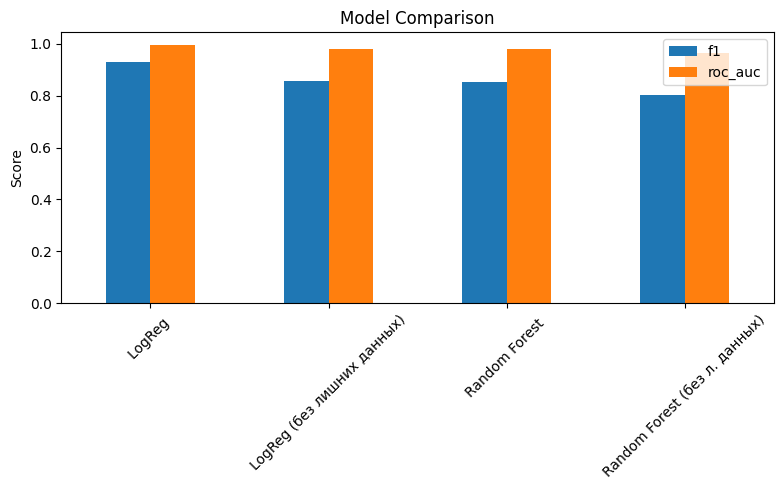

In [19]:
comparison_all[["f1", "roc_auc"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В ходе работы я сравнил две модели сначала на полном наборе данных, а потом после удаления признаков, которые могли давать утечку информации. По результатам лучше всего себя показала логистическая регрессия на полном наборе данных: у неё самые высокие значения accuracy, F1 и ROC-AUC. Но такие результаты выглядят слишком хорошими, поэтому я считаю, что часть признаков действительно могла подсказывать ответ модели.

После удаления лишних признаков качество у обеих моделей немного снизилось, и это нормально, потому что модель стала решать задачу честнее.

В итоге я бы выбрал Logistic Regression без признаков, связанных с утечкой, потому что она даёт хорошее качество и выглядит более корректной для реального применения.